This is a tutorial on how to use this 2D FMM RCWA code.

In [1]:
import RCWA_project.base as base
import RCWA_project.materials as mat
import RCWA_project.bunch as bunch
import RCWA_project.fields as fields
import numpy as np
import matplotlib.pyplot as plt

# Simple imports

In [2]:
# Computation parameters: nb of modes and stretching coefficient
Mm = 3
Nm = 0
eta = 0.999 # between 0 and 1 (but never exactly 1) Empirically, very close to 1 works really well

# Structure parameters: size of a MIM resonator
hcube = 7.0               # height of the cube
hspacer = 5.0            # height of the spacer
l_cubex = 7.0           # cube width along axis x
space_x = 21.1-l_cubex     # period along x (RCWA nerd advice, never use an exactly round period)
period = space_x + l_cubex

eps_dielec = 1.5**2        # spacer permittivity
metal_perm = mat.epsAubb   # metal permittivity

# Incidence parameters
lambdas = np.linspace(800, 1000, 10) # Being a 3D simulation, each point in parameter space can take a few seconds on a reasonable computer
theta = 0.0 * np.pi/180.
phi = 0.0 * np.pi/180.
pol = 0*np.pi/180.

# Results will be saved here
r = np.zeros(len(lambdas), dtype=complex)

In [3]:
dy = 1.2

top = bunch.Bunch() # The top layer (air)
top.ox = [0, l_cubex,l_cubex+space_x]
top.nx = [0, l_cubex,l_cubex+space_x]
top.oy = [0,dy]
top.ny = [0,dy]
top.Mm=Mm
top.Nm=Nm
top.mu =  np.array([[1, 1]])
top.eps =  np.array([[1, 1]])

top.eta=eta
top.pmlx=[0, 0]
top.pmly=[0]

bot = bunch.Bunch() # The substrate layer (gold)
bot.ox = [0, l_cubex,l_cubex+space_x]
bot.nx = [0, l_cubex,l_cubex+space_x]
bot.oy = [0,dy]
bot.ny = [0,dy]
bot.Mm=Mm
bot.Nm=Nm
bot.mu = np.array([[1, 1]])
bot.eta=eta
bot.pmlx=[0, 0]
bot.pmly=[0]


spa = bunch.Bunch() # The spacer layer (dielectric)
spa.ox = [0, l_cubex,l_cubex+space_x]
spa.nx = [0, l_cubex,l_cubex+space_x]
spa.oy = [0,dy]
spa.ny = [0,dy]
spa.Mm=Mm
spa.Nm=Nm
spa.mu =  np.array([[1, 1]])
spa.eps =  np.array([[eps_dielec, eps_dielec]])
spa.eta=eta
spa.pmlx=[0, 0]
spa.pmly=[0]

gp = bunch.Bunch() # The cube layer, structured
gp.ox = [0, l_cubex,l_cubex+space_x]
gp.nx = [0, l_cubex,l_cubex+space_x]
gp.oy = [0,dy]
gp.ny = [0,dy]
gp.Mm = Mm
gp.Nm = Nm
gp.mu = np.array([[1, 1]])
gp.eta = eta
gp.pmlx=[0, 0]
gp.pmly=[0]

Since we loop on lambdas, the permittivities for layers that are wavelength dependent are defined later, as well as all parameters that are related to k:
- k0 the wavevector in vacuum
- kx the projection along axis x
- ky the projection along axis y

And then the main computation is done!

Note:
The `P` vectors correspond to the eigen vectors of the problem in each layer, but:

- The first half is only the eigen vector $U$

- The second half is $L U \Gamma^{-1}$, as needed for the S matrix formulation

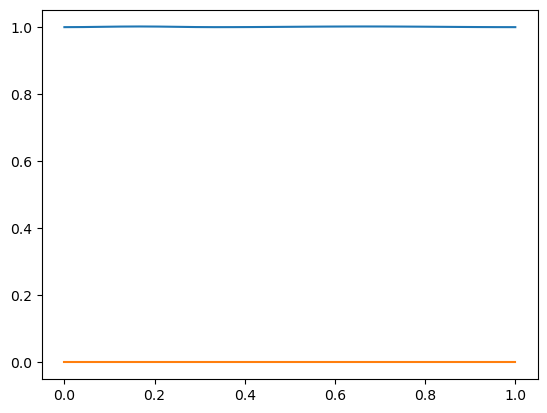

In [4]:
Mm = 6
Nm = 0
eta = 0.001 # between 0 and 1 (but never exactly 1) Empirically, very close to 1 works really well

nx = len(top.pmlx)*(2*Mm+1)
xs_fft = np.linspace(0, 1, nx - 1)
fprime = fields.f_prime(top.ox, eta, xs_fft*period)
plt.plot(xs_fft, np.real(fprime))
plt.plot(xs_fft, np.imag(fprime))


In [5]:

lambd = 50
top.eta = eta
spa.eta = eta
bot.eta = eta
gp.eta = eta
top.Mm = Mm
spa.Mm = Mm
bot.Mm = Mm
gp.Mm = Mm
e_au = metal_perm(lambd)
k0 = 2*np.pi/lambd
top.k0 = k0
spa.k0 = k0
bot.k0 = k0
gp.k0 = k0
kx = -k0 * np.sin(theta) * np.cos(phi)
top.kx = kx
bot.kx = kx
spa.kx = kx
gp.kx = kx
ky = -k0 * np.sin(theta) * np.sin(phi)
top.ky = ky
bot.ky = ky
spa.ky = ky
gp.ky = ky

print(kx)

bot.eps =  np.array([[e_au]])
gp.eps = np.array([[e_au]])  # This is the structured layer, with the metallic part being between ox[0] and ox[1]

# Now that everything is defined, we can compute the modes in each structure!


[Pair,Vair], ext_top = base.homogene(top, ext=1)
# This is the incidence layer, so we add the "ext" argument and returned variable, for later

print(ext_top)
# [Pgp,Vgp] = base.reseau(gp)      # This is the structured layer
[Pspa,Vspa], ext_bot = base.homogene(spa, ext=1) # These are homogeneous layers, we leverage this
# # [Psub,Vsub] = base.homogene(bot) # These are homogeneous layers, we leverage this

# print(ext_bot)


-0.0
[[ 1.        +0.j  0.12566371+0.j]
 [ 0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j]
 [12.        +0.j 14.        +0.j]]


/home/denis/Documents/git/Code_RCWA/RCWA_project/base.py:529: ComplexWarning: Casting complex values to real discards the imaginary part
  V[int(ana_kz[3, i_mod])] = ana_kz[0, i_mod]
/home/denis/Documents/git/Code_RCWA/RCWA_project/base.py:557: ComplexWarning: Casting complex values to real discards the imaginary part
  for j in range(int(ana_kz[0, 0])):
/home/denis/Documents/git/Code_RCWA/RCWA_project/base.py:586: ComplexWarning: Casting complex values to real discards the imaginary part
  E[: n * m, int(ana_kz[3, j])] = alpha @ vtmp
/home/denis/Documents/git/Code_RCWA/RCWA_project/base.py:587: ComplexWarning: Casting complex values to real discards the imaginary part
  E[n * m :, int(ana_kz[3, j + np.shape(ana_kz)[1] // 2])] = beta @ vtmp


In [6]:
from RCWA_project.base import interface, cascade, c_up, c_down
from RCWA_project.fields import E_field, f_prime

def myField_2D(Ps, Vs, thickness, interf, eta, wavelength, angle, ext, z_res, x_res, n_mod, period):
    """
    Hopefully, computing fields
    QO:
        - in 2D, we normalise wrt the period. Can we not do this in 3D?
            Fix idea: if we only ever compute 2D maps (slices), then the period makes sens again
    """

    # Normalisation
    wavelength_norm = wavelength / period

    thickness = np.array([t / period for t in thickness])

    k0 = 2 * np.pi / wavelength_norm
    alpha_0 = k0 * np.sin(angle)

    n_mod_total = 2 * (2 * n_mod + 1)  # Ex and Ey modes

    n_layers = thickness.size

    # matrice neutre pour l'opération de cascadage
    S11 = np.zeros((n_mod_total, n_mod_total))
    S12 = np.eye(n_mod_total)
    S0 = np.block([[S11, S12], [S12, S11]])
    S_down = []
    S_down.append(S0)

    # matrices d'interface
    B = []
    for k in range(n_layers - 1):  # car nc - 1 interfaces dans la structure
        c = interface(Ps[k], Ps[k + 1])
        B.append(c)

    # Matrices descendantes
    for k in range(n_layers - 1):
        # a = np.array(S_down[k])
        b = c_up(np.array(B[k]), np.array(Vs[k]), thickness[k])
        S_new = cascade(S_down[k], b)
        S_down.append(S_new)

    a = np.array(S_down[n_layers - 1])
    b = np.array(Vs[n_layers - 1])
    c = c_down(a, b, thickness[n_layers - 1])
    S_down.append(c.tolist())

    # Matrices montantes
    S_up = []
    S_up.append(S0)

    for k in range(n_layers - 1):
        a = np.array(B[n_layers - k - 2])
        b = np.array(Vs[n_layers - (k + 1)])
        c = thickness[n_layers - (k + 1)]
        d = np.array(S_up[k])
        S_new = cascade(c_down(a, b, c), d)
        S_up.append(S_new)
    print(k, n_layers, len(S_up))

    # a = np.array(S_up[k])
    # b = np.array(Vs[0])
    c = c_up(S_up[n_layers-2], Vs[0], thickness[0])
    S_up.append(c)

    exc = np.zeros(2 * n_mod_total)  # excitation
    # Eclairage par au dessus, onde plane
    print(np.shape(exc))
    exc = ext
    print(np.shape(exc))
    # eclairage par en dessous, onde plane
    # exc[n_mod_total + n_mod] = 1
    # eclairage par en dessous, guide d'onde (le mode avec la plus grande partie réelle)
    # position = np.argmax(np.real(Vdown))

    ny = np.floor(thickness * period / z_res)
    print("sizes", ny)
# for i in range (2* n_mod_total):

#     exc = np.zeros(2 * n_mod_total)  # excitation
#     # Eclairage par au dessus, onde plane
#     exc[i] = 1
#     if(i == ext):
#         print("POP")
    Ex, Ey = E_field(
        np.array(S_down[0]),
        np.array(S_up[n_layers - 0 - 1]),
        np.array(Vs[0]),
        np.array(Ps[0]),
        exc,
        int(ny[0]),
        thickness[0],
        alpha_0,
    )

    for j in np.arange(1, n_layers):
        Ex_new, Ey_new, = E_field(
            np.array(S_down[j]),
            np.array(S_up[n_layers - j - 1]),
            np.array(Vs[j]),
            np.array(Ps[j]),
            exc,
            int(ny[j]),
            thickness[j],
            alpha_0,
        )
        Ex = np.append(Ex, Ex_new, 0)
        Ey = np.append(Ey, Ey_new, 0)
    

    nx = int(np.shape(S_down[0])[0] / 2)
    xs_fft = np.linspace(0, 1, nx - 1)
    xs_real = np.arange(0, 1, x_res/period)
    # print(np.shape(M), np.shape(xs_fft), nx, np.shape(S_down), xs_real)

    z_len = len(Ex)
    Ex_real = np.zeros((z_len, len(xs_real)), dtype=complex)
    mem = np.array(Ex)
    fprime = f_prime(interf, eta, xs_fft*period)
    for i in range(z_len):
        # print("pop", fprime)
        Ex_real[i] = np.interp(xs_real, xs_fft, Ex[i] / (fprime*np.exp(1.0j*alpha_0 * fprime)), period=1)

    z_len = len(Ey)
    Ey_real = np.zeros((z_len, len(xs_real)), dtype=complex)
    mem = np.array(Ey)
    fprime = f_prime(interf, eta, xs_fft*period)
    for i in range(z_len):
        # print("pop", fprime)
        Ey_real[i] = np.interp(xs_real, xs_fft, Ey[i] / (fprime*np.exp(1.0j*alpha_0 * fprime)), period=1)


    # Mfield = np.abs(M) ** 2
    plt.figure(i)
    plt.subplot(2, 1, 1)
    plt.imshow(np.real(Ex))
    plt.subplot(2, 1, 2)
    plt.imshow(np.real(Ey))
    plt.subplot(2, 2, 1)
    plt.imshow(np.real(Ex_real))
    plt.subplot(2, 2, 2)
    plt.imshow(np.real(Ey_real))
    plt.show()


(52, 26)
inc 0.0 0.0 0.0
0 2 2
(52,)
(52,)
sizes [30. 30.]
E_field 26 (52, 1) (26, 26)
test1 (26, 1)
test2 (26, 26)
test3 (26, 1) [[ 1.22630116e-06+7.74483245e-07j]
 [ 7.93658988e-05-4.12110236e-05j]
 [ 1.31699674e-05-2.65143698e-04j]
 [-4.75062603e-04-3.10019925e-04j]
 [-1.28332014e-03+6.42293607e-04j]
 [ 4.09851849e-05-6.34357145e-04j]
 [ 2.80698903e+00+1.89198723e+00j]
 [-5.72629888e-04+2.76014103e-04j]
 [ 1.13837594e-04-1.43055677e-03j]
 [-4.65621542e-04-3.24026867e-04j]
 [-2.40829550e-04+1.11694924e-04j]
 [-8.42030306e-06+8.90302918e-05j]
 [ 1.17802893e-06+8.46100867e-07j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+

ValueError: operands could not be broadcast together with shapes (12,) (25,) 

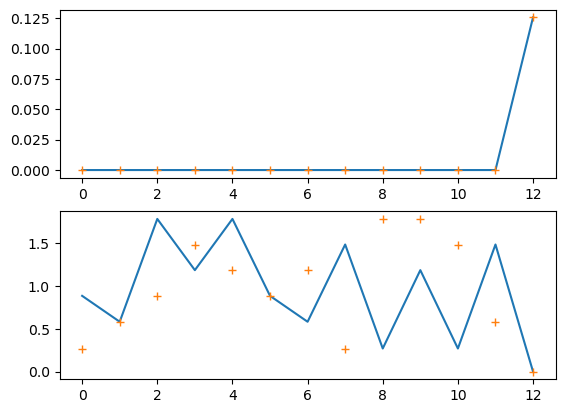

In [7]:

Ps = [Pair, Pspa]
Vs = [Vair, Vspa]
# Ps = [Pair, Pgp, Pspa, Psub]
# Vs = [Vair, Vgp, Vspa, Vsub]
print(np.shape(Pair))
# The modes computed so far do not take into accoun the polarization, so we could here computed the reflection coefficients for different polarizations.
# But for simplicity, we will consider the polarisation defined at the beginning
Ex = np.cos(pol) * np.cos(theta) * np.cos(phi) - np.sin(pol) * np.sin(phi) # Ex incident
Ey = np.cos(pol) * np.cos(theta) * np.sin(phi) + np.sin(pol) * np.cos(phi) # Ey incident
eps_k2 = top.eps[0,0] * top.mu[0,0] * top.k0**2 # eps k^2
d = np.sqrt(eps_k2 - top.kx**2 - top.ky**2) # norm k
# e = normalisation E
norm = ((eps_k2-top.ky**2)*np.abs(Ex)**2 + (eps_k2-top.kx**2)*np.abs(Ey)**2 + 2*top.kx*top.ky*np.real(Ex*Ey)) / (top.mu[0,0]*d)

V_inc = np.zeros(4 * (2*Nm+1) *(2*Mm+1))
V_inc[int(np.real(ext_top[3,0]))] = Ex/np.sqrt(norm)
V_inc[int(np.real(ext_top[3,int(np.real(ext_top[0,0]))]))] = Ey/np.sqrt(norm)

thickness = np.array([3000, 3000])

# plt.imshow(np.log(np.abs(Pair)))
Vair1 = np.sort(Vair[:2*Mm+1])
Vair2 = np.sort(Vair[2*Mm+1:])
plt.subplot(2, 1, 1)
plt.plot(np.real(Vair1))
plt.plot(np.real(Vair2), '+')
plt.subplot(2, 1, 2)
plt.plot(np.imag(Vair1))
plt.plot(np.imag(Vair2), '+')

z_res = 100
x_res = 1
print("inc", theta, phi, pol)
myField_2D(Ps, Vs, thickness, top.ox, eta, lambd, theta, V_inc, z_res, x_res, Mm, period)


In [10]:
# print(M)
plt.figure(2)
M[:, :2] = 0.15
plt.imshow(np.real(M), aspect='auto')
plt.figure(3)
M[:, :2] = 0.15
plt.imshow(np.real(mem), aspect='auto')



NameError: name 'M' is not defined

<Figure size 640x480 with 0 Axes>

/home/denis/miniconda3/envs/myenv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/denis/miniconda3/envs/myenv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


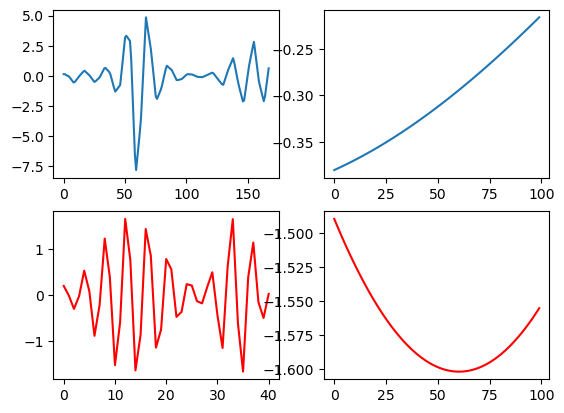

In [7]:
plt.subplot(2,2,1)
plt.plot(M[10])
plt.subplot(2,2,2)
plt.plot(M[:,10])
plt.subplot(2,2,3)
plt.plot(mem[10], 'r')
plt.subplot(2,2,4)
plt.plot(mem[:,10], 'r')

# print(M)
# plt.imshow(M/np.max(M))
# plt.colorbar()

# Stop here

In [21]:
# Computation parameters: nb of modes and stretching coefficient
Mm = 20
Nm = 0
eta = 0.999 # between 0 and 1 (but never exactly 1) Empirically, very close to 1 works really well

# Structure parameters: size of a MIM resonator
hcube = 40.0               # height of the cube
hspacer = 2.5            # height of the spacer
l_cubex = 40.0           # cube width along axis x
space_x = 80.02-l_cubex     # period along x (RCWA nerd advice, never use an exactly round period)
period = space_x + l_cubex

eps_dielec = 2.0**2        # spacer permittivity
metal_perm = mat.epsAubb   # metal permittivity

# Incidence parameters
lambdas = np.linspace(400, 2000, 50) # Being a 3D simulation, each point in parameter space can take a few seconds on a reasonable computer
theta = 0.0 * np.pi/180.
phi = 0.0 * np.pi/180.
pol = 0*np.pi/180.

# Results will be saved here
r = np.zeros(len(lambdas), dtype=complex)
dy = 1.2

top = bunch.Bunch() # The top layer (air)
top.ox = [0,l_cubex,l_cubex+space_x]
top.nx = [0,l_cubex,l_cubex+space_x]
top.oy = [0,dy]
top.ny = [0,dy]
top.Mm=Mm
top.Nm=Nm
top.mu =  np.array([[1.,1]])
top.eps =  np.array([[1.,1]])

top.eta=eta
top.pmlx=[0, 0]
top.pmly=[0]

bot = bunch.Bunch() # The substrate layer (gold)
bot.ox = [0,l_cubex,l_cubex+space_x]
bot.nx = [0,l_cubex,l_cubex+space_x]
bot.oy = [0,dy]
bot.ny = [0,dy]
bot.Mm=Mm
bot.Nm=Nm
bot.mu = np.array([[1.,1]])
bot.eta=eta
bot.pmlx=[0, 0]
bot.pmly=[0]


spa = bunch.Bunch() # The spacer layer (dielectric)
spa.ox = [0,l_cubex,l_cubex+space_x]
spa.nx = [0,l_cubex,l_cubex+space_x]
spa.oy = [0,dy]
spa.ny = [0,dy]
spa.Mm=Mm
spa.Nm=Nm
spa.mu =  np.array([[1.,1]])
spa.eps =  np.array([[eps_dielec,eps_dielec]])
spa.eta=eta
spa.pmlx=[0, 0]
spa.pmly=[0]

gp = bunch.Bunch() # The cube layer, structured
gp.ox = [0,l_cubex,l_cubex+space_x]
gp.nx = [0,l_cubex,l_cubex+space_x]
gp.oy = [0,dy]
gp.ny = [0,dy]
gp.Mm = Mm
gp.Nm = Nm
gp.mu = np.array([[1.,1]])
gp.eta = eta
gp.pmlx=[0, 0]
gp.pmly=[0]

for i, lambd in enumerate(lambdas):
    print(int(lambd), end=" ")
    e_au = metal_perm(lambd)
    k0 = 2*np.pi/lambd
    top.k0 = k0
    spa.k0 = k0
    bot.k0 = k0
    gp.k0 = k0
    kx = -k0 * np.sin(theta) * np.cos(phi)
    top.kx = kx
    bot.kx = kx
    spa.kx = kx
    gp.kx = kx
    ky = -k0 * np.sin(theta) * np.sin(phi)
    top.ky = ky
    bot.ky = ky
    spa.ky = ky
    gp.ky = ky

    bot.eps =  np.array([[e_au,e_au]])
    gp.eps = np.array([[e_au,1.]])  # This is the structured layer, with the metallic part being between ox[0] and ox[1]
    
    # Now that everything is defined, we can compute the modes in each structure!

    
    [Pair,Vair], ext = base.homogene(top, ext=1) # This is the incidence layer, so we add the "ext" argument and returned variable, for later

    [Pgp,Vgp] = base.reseau(gp)      # This is the structured layer
    [Pspa,Vspa] = base.homogene(spa) # These are homogeneous layers, we leverage this
    [Psub,Vsub] = base.homogene(bot) # These are homogeneous layers, we leverage this

    # The P's are eigenvectors of the layer, i.e. the mode distributions
    # The V's are eigenvalues of the layer, i.e. kz^2


    # Normally, the eigenvalues with very small imaginary values (numerical error sized imaginary parts) have already been projected to the real axis
    # but we're never too sure.
    Vair = np.real(Vair) * (np.abs(np.real(Vair))>1e-10) + 1.0j*(np.imag(Vair) * (np.abs(np.imag(Vair))>1e-10))
    
    # Using the modes computed, we now compute the S matrix of the whole system
    S = base.c_down(base.interface(Pair, Pgp), Vgp, hcube)
    S = base.cascade(S, base.c_down(base.interface(Pgp, Pspa), Vspa, hspacer))
    S = base.cascade(S, base.c_down(base.interface(Pspa, Psub), Vsub, 0))

    # Creating the entry vector, using the "ext" variable savec previously
    # pol = 0
    # The modes computed so far do not take into accoun the polarization, so we could here computed the reflection coefficients for different polarizations.
    # But for simplicity, we will consider the polarisation defined at the beginning
    Ex = np.cos(pol) * np.cos(theta) * np.cos(phi) - np.sin(pol) * np.sin(phi) # Ex incident
    Ey = np.cos(pol) * np.cos(theta) * np.sin(phi) + np.sin(pol) * np.cos(phi) # Ey incident
    eps_k2 = top.eps[0,0] * top.mu[0,0] * top.k0**2 # eps k^2
    d = np.sqrt(eps_k2 - top.kx**2 - top.ky**2) # norm k
    # e = normalisation E
    norm = ((eps_k2-top.ky**2)*np.abs(Ex)**2 + (eps_k2-top.kx**2)*np.abs(Ey)**2 + 2*top.kx*top.ky*np.real(Ex*Ey)) / (top.mu[0,0]*d)
    
    V_inc = np.zeros(4 * (2*Nm+1) *(2*Mm+1))
    V_inc[int(np.real(ext[3,0]))] = Ex/np.sqrt(norm)
    V_inc[int(np.real(ext[3,int(np.real(ext[0,0]))]))] = Ey/np.sqrt(norm)

    V_out = S @ V_inc # outgoing fields
    V_r = V_out[:2 * (2*Nm+1) *(2*Mm+1)] # Just the reflected fields
    reflechi = base.efficace(top, ext, V_r)
    r[i] = reflechi[3,0]

    # We have no transmission in this case but this is how we would do it: 
    # V_t = V_out[2 * (2*Nm+1) *(2*Mm+1):] # Just the transmitted fields
    # transm = base.efficace(top, ext, V_t)
    # t[i] = transm[3,0]

400 432 465 497 530 563 595 628 661 693 726 759 791 824 857 889 922 

KeyboardInterrupt: 

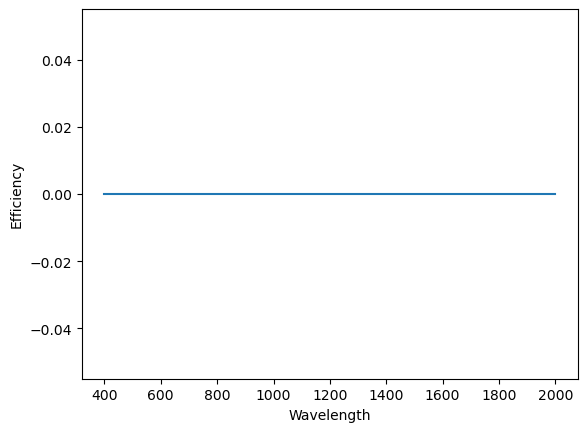

In [20]:
# print(r)
plt.plot(lambdas, np.abs(r))
plt.xlabel("Wavelength")
plt.ylabel("Efficiency")
plt.show()